In [1]:
# add parent to path
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent.parent))

from plots.wandb_utils import combine_histories, get_wandb_stats

# tpc-h bespoke storage linearge
run_ids = [
    # # initial submission
    # "nhpul25g",  # plan storage
    # "a2tlnfrk",  # basic impl
    # "h1mv9o9r",  # optim
    # revision
    # "7hgw64uc",  # plan storage
    # "rkx580eu",  # basic
    # "4t7jyv2f",  # optim
    # "szm0buc8",  # plan storage
    # "h625m177",  # basic
    # "9nbjhhmf",  # optim
    # claude
    # "zr53vfdu",  # plan storage
    # "0v8vc8xw",  # basic
    # "w6hdaw6e",  # optim
    # 3/16/2026
    "szm0buc8",  # storage
    "osfnlgy4",  # base
    "xqr85l1q",  # optim
]


# run_id = "k9xst454"  # tpch - bespoke storage
# run_id = "ggikqms8"  # ceb
# run_id = "761bg8oe"  # ceb - bespoke storage

hists_list = []
for run_id in run_ids:
    summary, hist, config = get_wandb_stats(
        run_id,
        skip_cache=True,  # set to True to skip cache and fetch from W&B API
        wandb_run_cache_path=Path("/mnt/labstore/bespoke_olap/wandb_cache"),
    )
    hists_list.append(hist)


combined_history = combine_histories(hists_list)
combined_history = combined_history.sort_values("_step")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/jwehrstein/.netrc.


✓ Run loaded: tpch_storageplan1-22v1
  State: finished
  Created: 2026-03-12T06:17:32Z
✓ Data fetched: 7 turns, 35 columns
✓ W&B data cached to: /mnt/labstore/bespoke_olap/wandb_cache/fa86840d462c3a0aaa5be10b5e96478befc9f65072da208cd882005810b6e2a1.pkl
✓ Run loaded: tpch_initial1-22v2017_wstorage
  State: finished
  Created: 2026-03-16T16:08:13Z
✓ Data fetched: 1249 turns, 148 columns
✓ W&B data cached to: /mnt/labstore/bespoke_olap/wandb_cache/5b33965f31e508100cb883ffc844e186ae9f2dd02e62076e21abde65bd25dc6a.pkl
✓ Run loaded: tpch_optim1-22v1001_wstorage
  State: failed
  Created: 2026-03-16T19:42:16Z
✓ Data fetched: 582 turns, 137 columns
✓ W&B data cached to: /mnt/labstore/bespoke_olap/wandb_cache/b36010eb9fef9db8ea55a61b8319b8fbbab5b81804716d02f111cdfd0ad93a0d.pkl
Combined history has 1838 rows ([7, 1249, 582])


Total runtime by type (seconds):
       type  runtime_seconds
        llm     12506.693678
   validate      7958.441580
    compile      1023.431168
 compaction       776.388049
 supervisor       306.186150
      shell        96.592021
apply_patch         5.100739


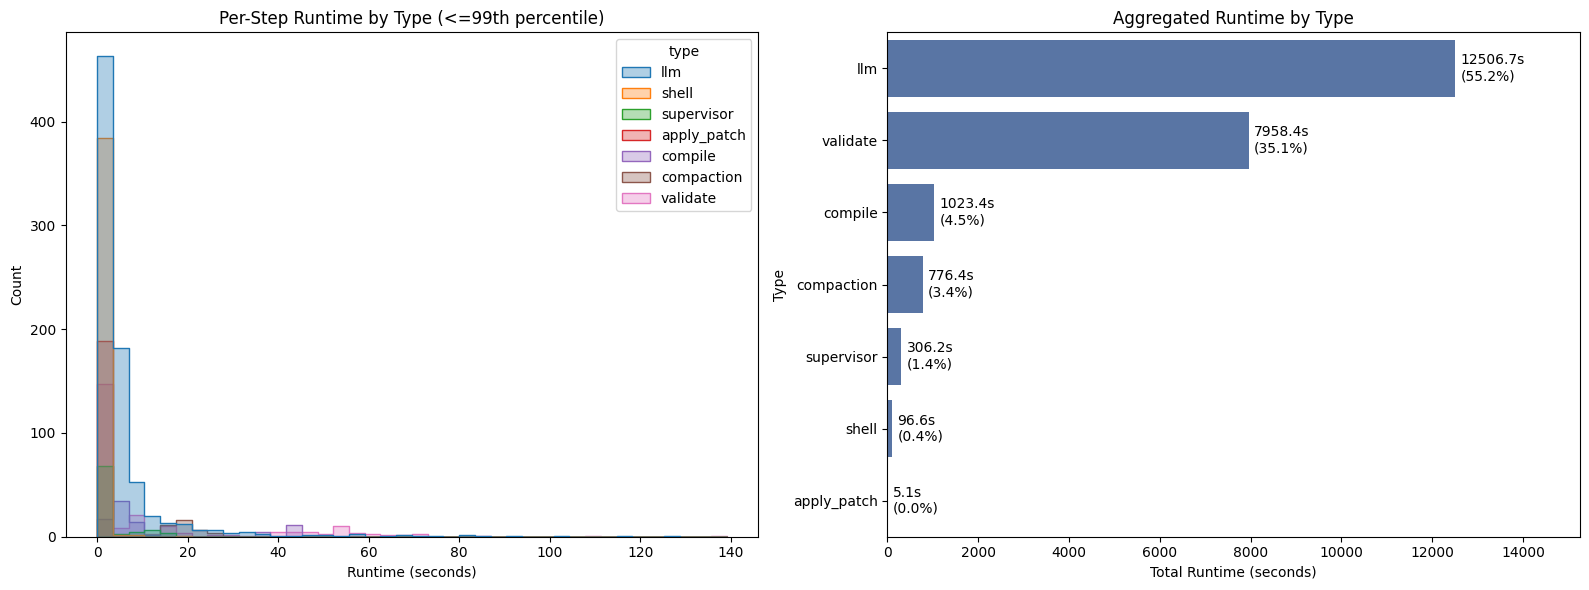

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

if "type" not in combined_history.columns:
    print("Missing required column: type")

assert "total/runtime" in combined_history.columns


df = combined_history[["type", "total/runtime"]].dropna().copy()

# Normalize equivalent type labels.
type_map = {
    "shell_command": "shell",
    "llm_call": "llm",
}
df["type"] = df["type"].replace(type_map)

# map type=llm and supervisor=True to type=supervisor
df.loc[
    (df["type"] == "llm") & (combined_history.get("supervisor", False) == True), "type"
] = "supervisor"

# Derive per-event runtime from cumulative runtime, restarting at run boundaries.
df["runtime_seconds"] = df["total/runtime"].diff()
reset_mask = df["runtime_seconds"].isna() | (df["runtime_seconds"] < 0)
df.loc[reset_mask, "runtime_seconds"] = df.loc[reset_mask, "total/runtime"]

# Keep only non-negative, finite durations.
df = df[(df["runtime_seconds"] >= 0) & pd.notna(df["runtime_seconds"])]

# Aggregate total runtime by type.
agg = (
    df.groupby("type", as_index=False)["runtime_seconds"]
    .sum()
    .sort_values("runtime_seconds", ascending=False)
    .reset_index(drop=True)
)
agg["runtime_minutes"] = agg["runtime_seconds"] / 60.0

print("Total runtime by type (seconds):")
print(agg[["type", "runtime_seconds"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Trim extreme outliers for readability in histogram (99th percentile).
p99 = df["runtime_seconds"].quantile(0.99)
plot_df = df[df["runtime_seconds"] <= p99]

sns.histplot(
    data=plot_df,
    x="runtime_seconds",
    hue="type",
    bins=40,
    element="step",
    stat="count",
    common_norm=False,
    alpha=0.35,
    ax=axes[0],
)
axes[0].set_title("Per-Step Runtime by Type (<=99th percentile)")
axes[0].set_xlabel("Runtime (seconds)")
axes[0].set_ylabel("Count")

bar_ax = sns.barplot(
    data=agg,
    x="runtime_seconds",
    y="type",
    orient="h",
    ax=axes[1],
    color="#4C72B0",
)

# Label each bar with total seconds and share of total runtime.
total_runtime = agg["runtime_seconds"].sum()
labels = [
    f"{v:.1f}s\n({(v / total_runtime * 100):.1f}%)"
    if total_runtime > 0
    else f"{v:.1f}s"
    for v in agg["runtime_seconds"]
]
bar_ax.bar_label(bar_ax.containers[0], labels=labels, padding=4)
max_runtime = agg["runtime_seconds"].max()
axes[1].set_xlim(0, max_runtime * 1.22 if max_runtime > 0 else 1)

axes[1].set_title("Aggregated Runtime by Type")
axes[1].set_xlabel("Total Runtime (seconds)")
axes[1].set_ylabel("Type")

plt.tight_layout()
plt.show()

In [3]:
if "_runtime" in combined_history.columns:
    df_all = combined_history.copy()
    df_all["runtime_seconds"] = df_all["_runtime"].diff()
    reset_mask = df_all["runtime_seconds"].isna() | (df_all["runtime_seconds"] < 0)
    df_all.loc[reset_mask, "runtime_seconds"] = df_all.loc[reset_mask, "_runtime"]
    df_all = df_all[
        (df_all["runtime_seconds"] >= 0) & pd.notna(df_all["runtime_seconds"])
    ]

    top10 = df_all.nlargest(10, "runtime_seconds").reset_index(drop=True)
    top10.index += 1

    # Build a readable "detail" column depending on entry type
    def make_detail(row):
        t = row.get("type", "")
        if t in ("shell_command", "shell"):
            cmds = row.get("shell/commands", "")
            if pd.notna(cmds) and cmds:
                first = str(cmds).split("\n")[0][:120]
                return first
        desc = row.get("current_prompt_descriptor", "")
        if pd.notna(desc) and desc:
            return str(desc)[:120]
        return ""

    top10["detail"] = top10.apply(make_detail, axis=1)

    want_cols = [
        "turn",
        "type",
        "agent_name",
        "runtime_seconds",
        "cost_usd",
        "input_tokens",
        "output_tokens",
        "reasoning_tokens",
        "detail",
    ]
    display_cols = [c for c in want_cols if c in top10.columns]

    rename_map = {
        "runtime_seconds": "runtime (s)",
        "cost_usd": "cost ($)",
        "input_tokens": "in_tok",
        "output_tokens": "out_tok",
        "reasoning_tokens": "reason_tok",
        "agent_name": "agent",
    }
    display(top10[display_cols].rename(columns=rename_map))


,turn,type,agent,runtime (s),cost ($),in_tok,out_tok,reason_tok,detail
1,1455,validate,NaN,330.513912,NaN,NaN,NaN,NaN,
2,1598,llm,Supervision Agent,320.577683,0.009090,3600.0,6.0,0.0,
3,1834,llm,Supervision Agent,291.918816,0.006247,8914.0,6.0,0.0,
4,1630,llm,Supervision Agent,279.103720,0.014855,5906.0,6.0,0.0,
5,1664,llm,Supervision Agent,275.441566,0.007445,2942.0,6.0,0.0,
6,1617,llm,Bespoke Assistant (Optim w. Sample Plan (5)),71.671177,0.011963,30962.0,34.0,0.0,
7,1620,shell,NaN,69.366486,NaN,NaN,NaN,NaN,"[""sed -n '760,920p' builder_impl.cpp""]"
8,1514,shell,NaN,67.733467,NaN,NaN,NaN,NaN,"['printf \'2 ""15"" ""BRASS"" ""EUROPE""\\n\' > /tmp..."
9,1593,llm,Bespoke Assistant (Optim w. Sample Plan (4)),61.893017,0.008983,28042.0,34.0,0.0,
10,1548,shell,NaN,58.853158,NaN,NaN,NaN,NaN,"['grep -R ""sorted_by_orderdate"" -n *.cpp *.hpp']"
